In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

In [2]:
log_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
log_df = load_accuracy_log(log_paths)

100%|██████████| 10922/10922 [00:32<00:00, 339.64it/s]


aggregate result by select the smallest test_l2

In [4]:
log_agg_df = log_df.groupby(['model', 'dataset', 'coarse_level','resolution','residual'])['test_l2'].apply(min).reset_index()

#### test relative L2 error on different residual type at same resolution

In [6]:
sub_df = log_agg_df[log_agg_df.coarse_level == 0]

In [11]:
pd.pivot_table(sub_df, values='test_l2', index=['model', 'dataset'], columns=['resolution', 'residual'])

resolution         512                                                      
residual           diag       ml1       ml2       ml3       ml4      null   
model dataset                                                               
fno1d burgers  0.003862  0.004054  0.004144  0.004263  0.004586  0.004493  \
      cosine   0.023794  0.022207  0.022333  0.024881  0.024613  0.022170   
      lnabs    0.015028  0.012843  0.012321  0.013443  0.013479  0.018937   
      poisson  0.009549  0.009845  0.010489  0.011968  0.011646  0.010769   
ft1d  burgers  0.023880  0.019067  0.022635  0.015010  0.014341  0.022776   
      cosine   0.012823  0.011334  0.013285  0.011149  0.013882  0.011048   
      lnabs    0.028564  0.031763  0.015537  0.012234  0.010131  0.028832   
      poisson  0.026679  0.024068  0.019783  0.012375  0.010871  0.022217   
gt1d  burgers  0.031888  0.023424  0.020457  0.015483  0.015252  0.029959   
      cosine   0.015527  0.011780  0.017544  0.011671  0.011136  0.012338   
      lnabs    0.028405  0.024632  0.015714  0.012171  0.009862  0.031196   
      poisson  0.016048  0.018088  0.015238  0.014092  0.010798  0.017270   
lno1d burgers  0.015224  0.016408  0.017464  0.016194  0.015339  0.039296   
      cosine   0.009906  0.009795  0.009546  0.011398  0.010726  0.023568   
      lnabs    0.022450  0.018719  0.015030  0.012496  0.011408  0.032318   
      poisson  0.011667  0.011147  0.011294  0.010139  0.009765  0.162138   

resolution         1024                                ...      2048   
residual           diag       ml1       ml2       ml3  ...       ml3   
model dataset                                          ...             
fno1d burgers  0.003848  0.003805  0.004379  0.004430  ...  0.004662  \
      cosine   0.021311  0.021861  0.020164  0.020166  ...  0.020583   
      lnabs    0.012991  0.010787  0.009982  0.010713  ...  0.009592   
      poisson  0.007465  0.007541  0.008274  0.009246  ...  0.007907   
ft1d  burgers  0.025084  0.017567  0.018648  0.013697  ...  0.015029   
      cosine   0.009719  0.008626  0.009088  0.008118  ...  0.009007   
      lnabs    0.025482  0.025577  0.017151  0.009957  ...  0.015161   
      poisson  0.025866  0.023308  0.016800  0.013666  ...  0.015151   
gt1d  burgers  0.029940  0.026897  0.019656  0.014550  ...  0.015942   
      cosine   0.023117  0.009748  0.010590  0.009253  ...  0.008310   
      lnabs    0.027258  0.025988  0.019845  0.012428  ...  0.017103   
      poisson  0.017010  0.013916  0.015832  0.012487  ...  0.011704   
lno1d burgers  0.015396  0.017894  0.021121  0.018955  ...  0.020990   
      cosine   0.007061  0.007205  0.006552  0.007394  ...  0.006480   
      lnabs    0.020516  0.019410  0.017228  0.012460  ...  0.014947   
      poisson  0.009957  0.010154  0.010148  0.009673  ...  0.009545   

resolution                             4096                                 
residual            ml4      null      diag       ml1       ml2       ml3   
model dataset                                                               
fno1d burgers  0.004762  0.004435       NaN       NaN       NaN       NaN  \
      cosine   0.019947  0.018413  0.021739  0.020566  0.020029  0.018490   
      lnabs    0.009715  0.017189  0.011980  0.011339  0.010328  0.009746   
      poisson  0.008347  0.005474       NaN       NaN       NaN       NaN   
ft1d  burgers  0.012061  0.019483       NaN       NaN       NaN       NaN   
      cosine   0.006975  0.007278       NaN       NaN       NaN       NaN   
      lnabs    0.008858  0.030941       NaN       NaN       NaN       NaN   
      poisson  0.009185  0.019118       NaN       NaN       NaN       NaN   
gt1d  burgers  0.015036  0.027484       NaN       NaN       NaN       NaN   
      cosine   0.009566  0.011120       NaN       NaN       NaN       NaN   
      lnabs    0.010432  0.030486       NaN       NaN       NaN       NaN   
      poisson  0.011135  0.016953       NaN       NaN       NaN       NaN   
lno1d burger

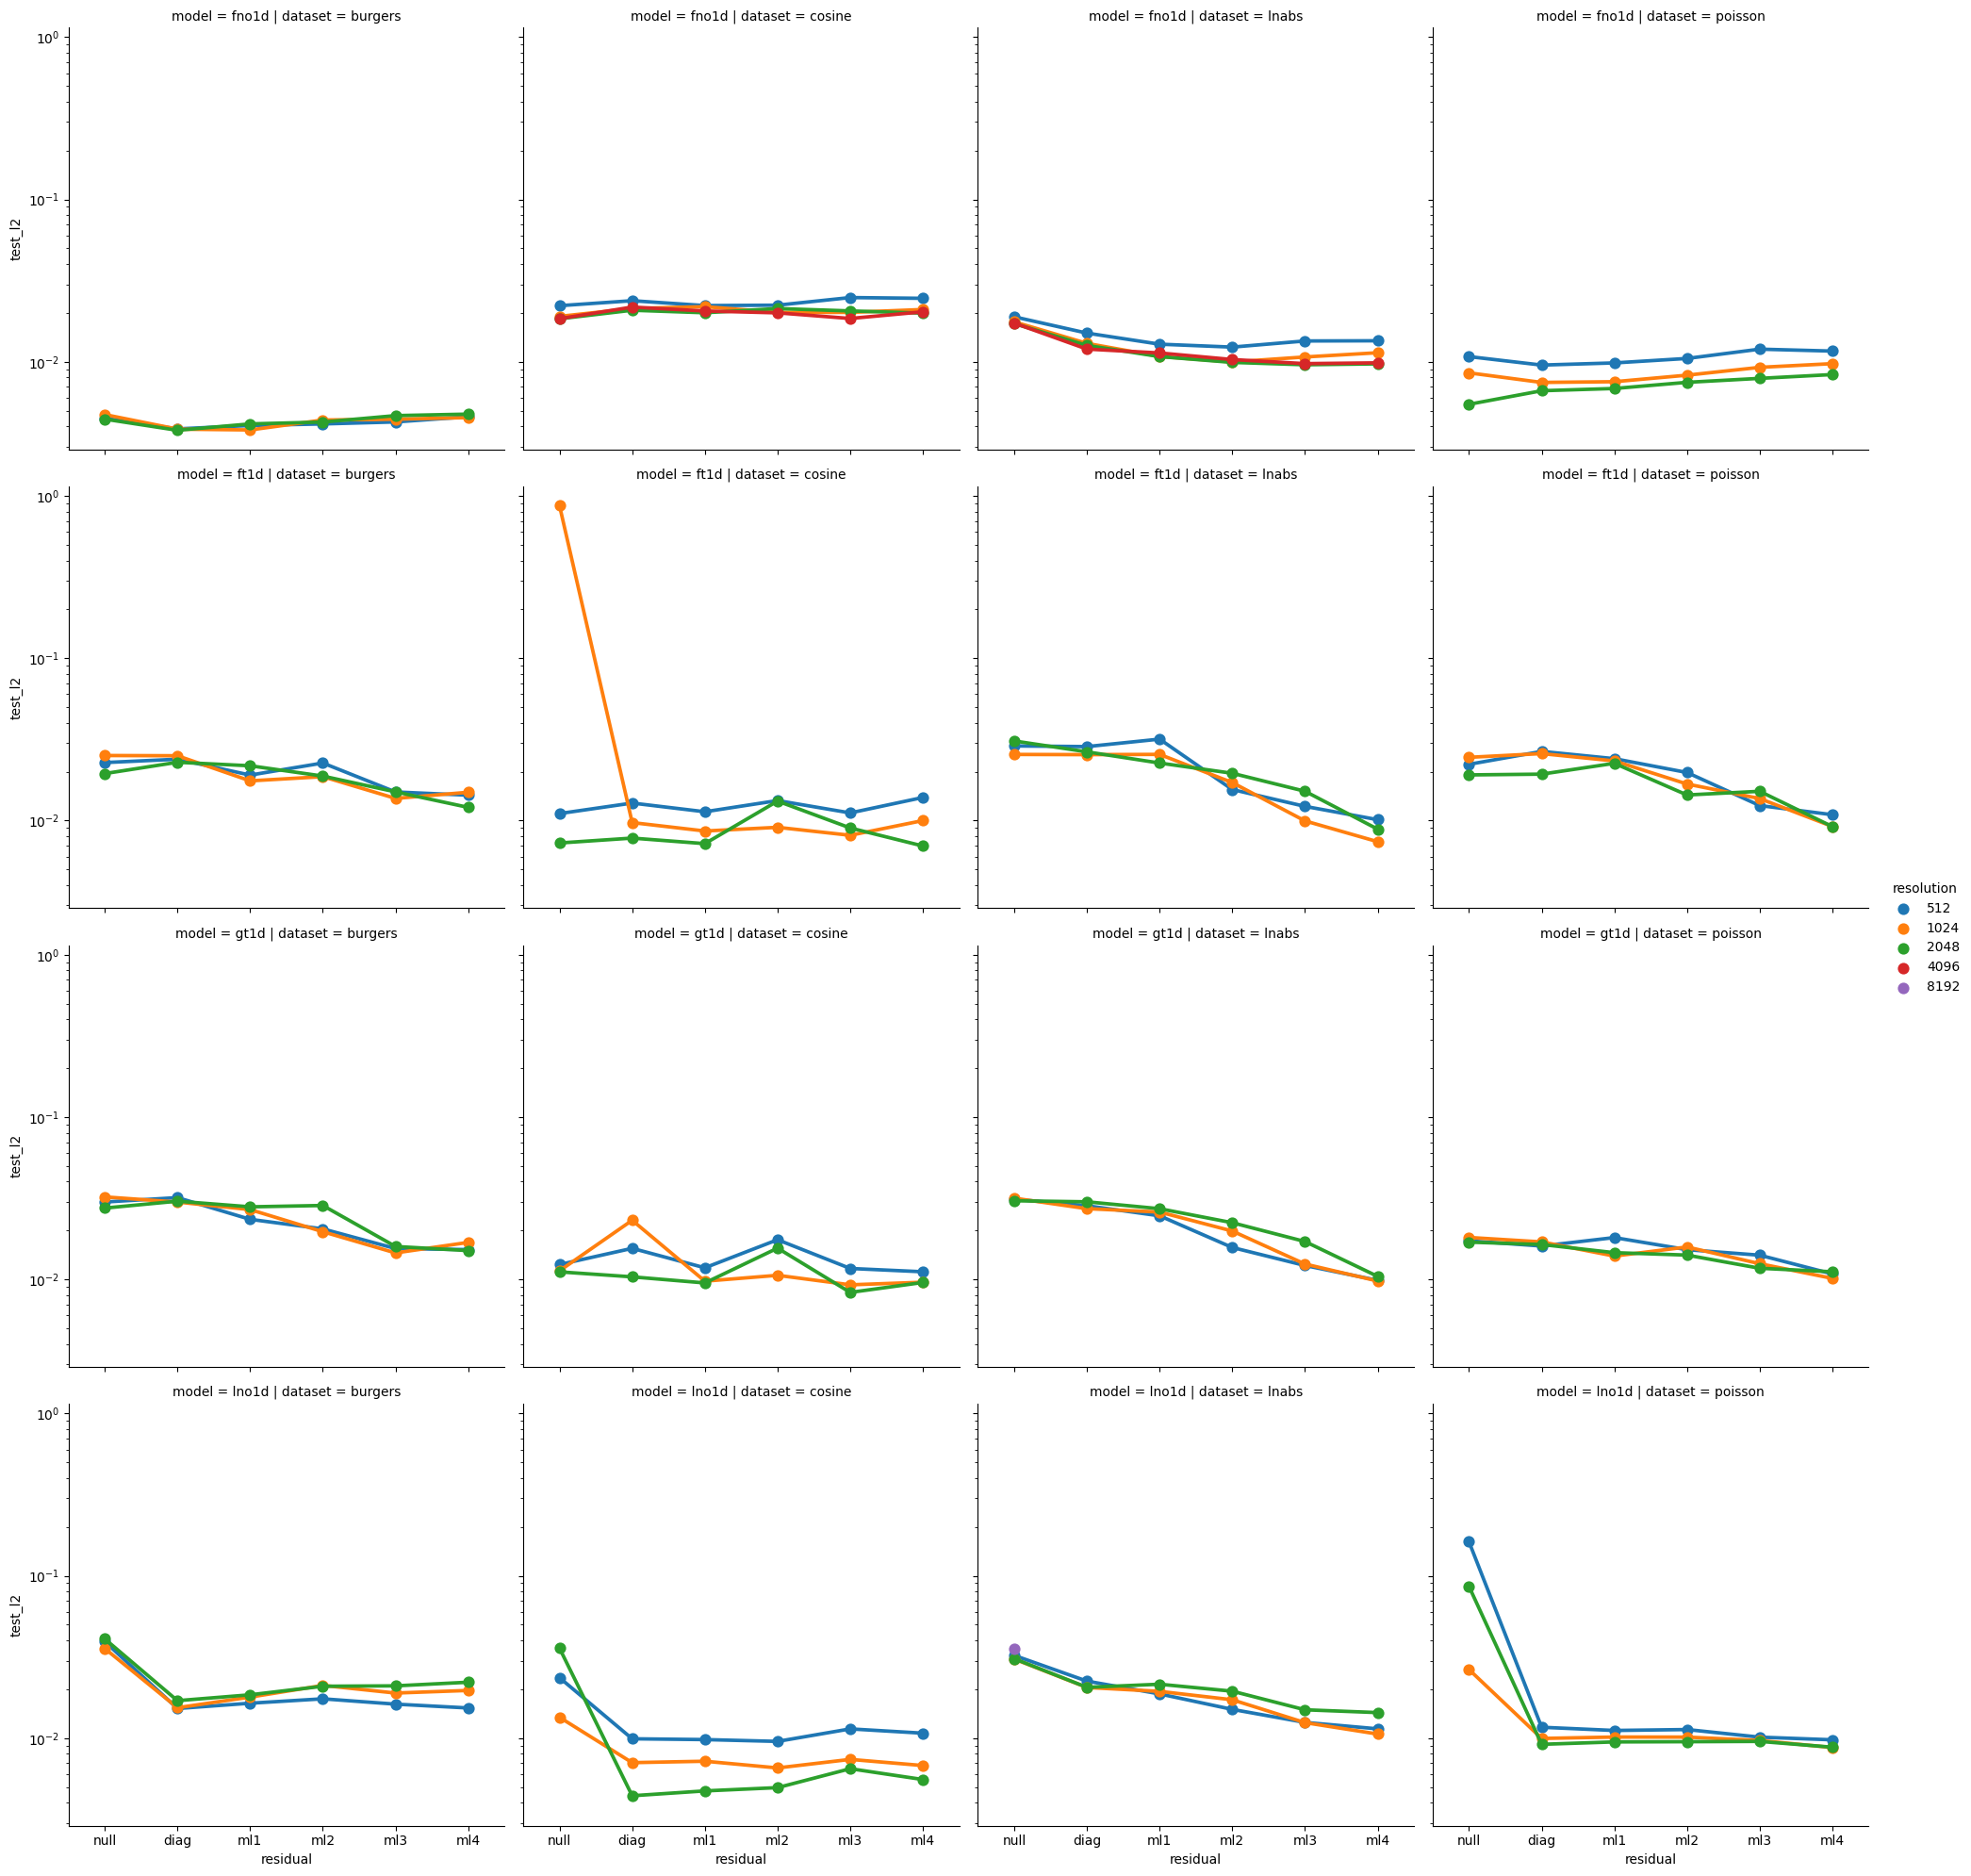

In [14]:
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', row='model', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='resolution')
g.set(yscale='log')

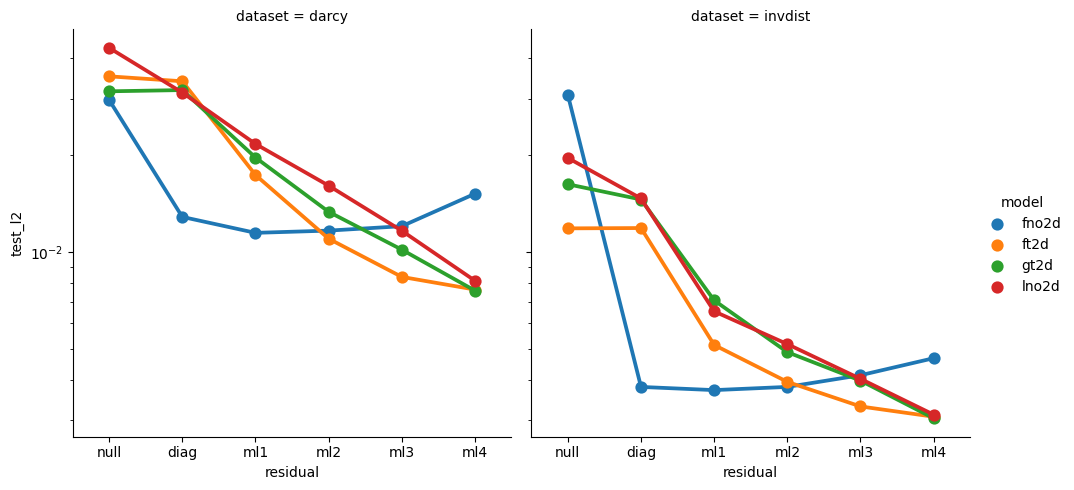

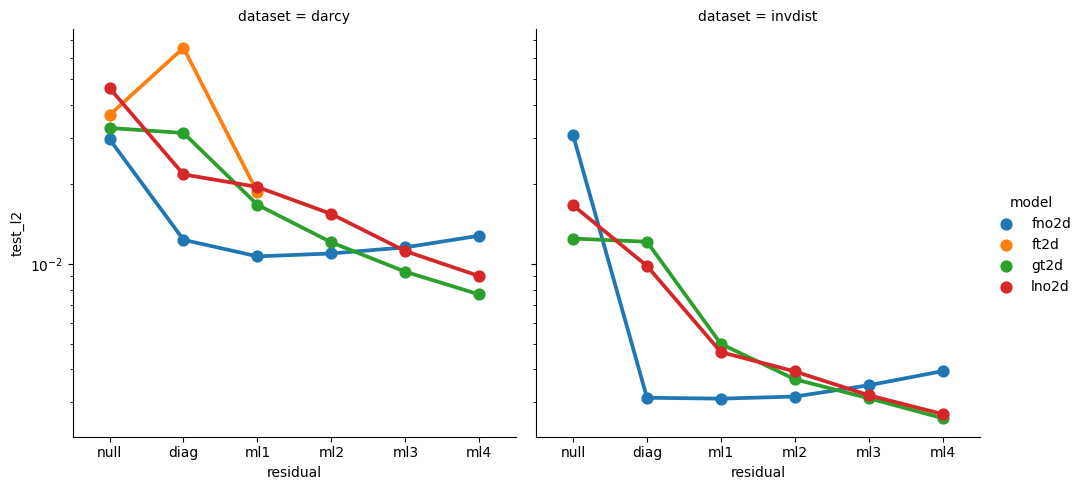

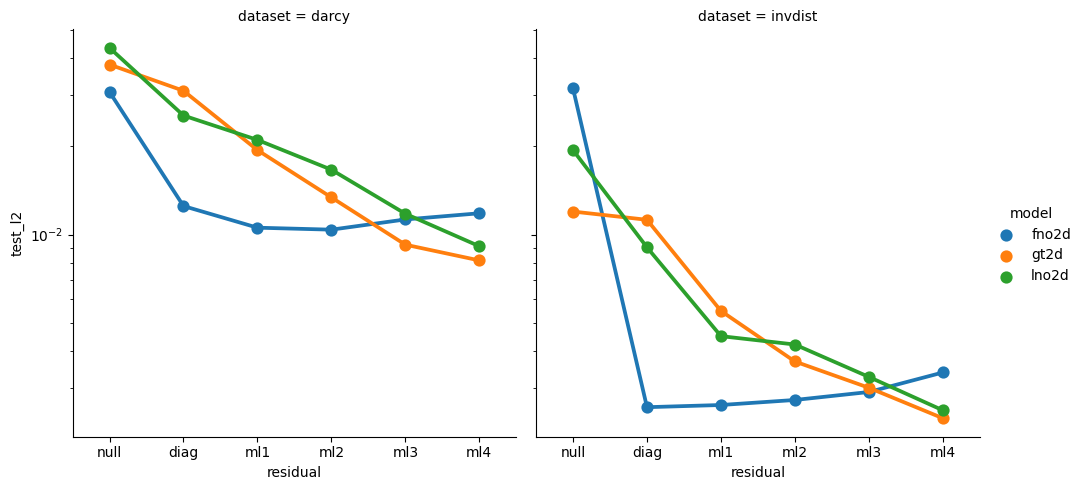

In [9]:
sub_df = log_agg_df[(log_agg_df.resolution == 85) & (log_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

sub_df = log_agg_df[(log_agg_df.resolution == 106) & (log_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

sub_df = log_agg_df[(log_agg_df.resolution == 141) & (log_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

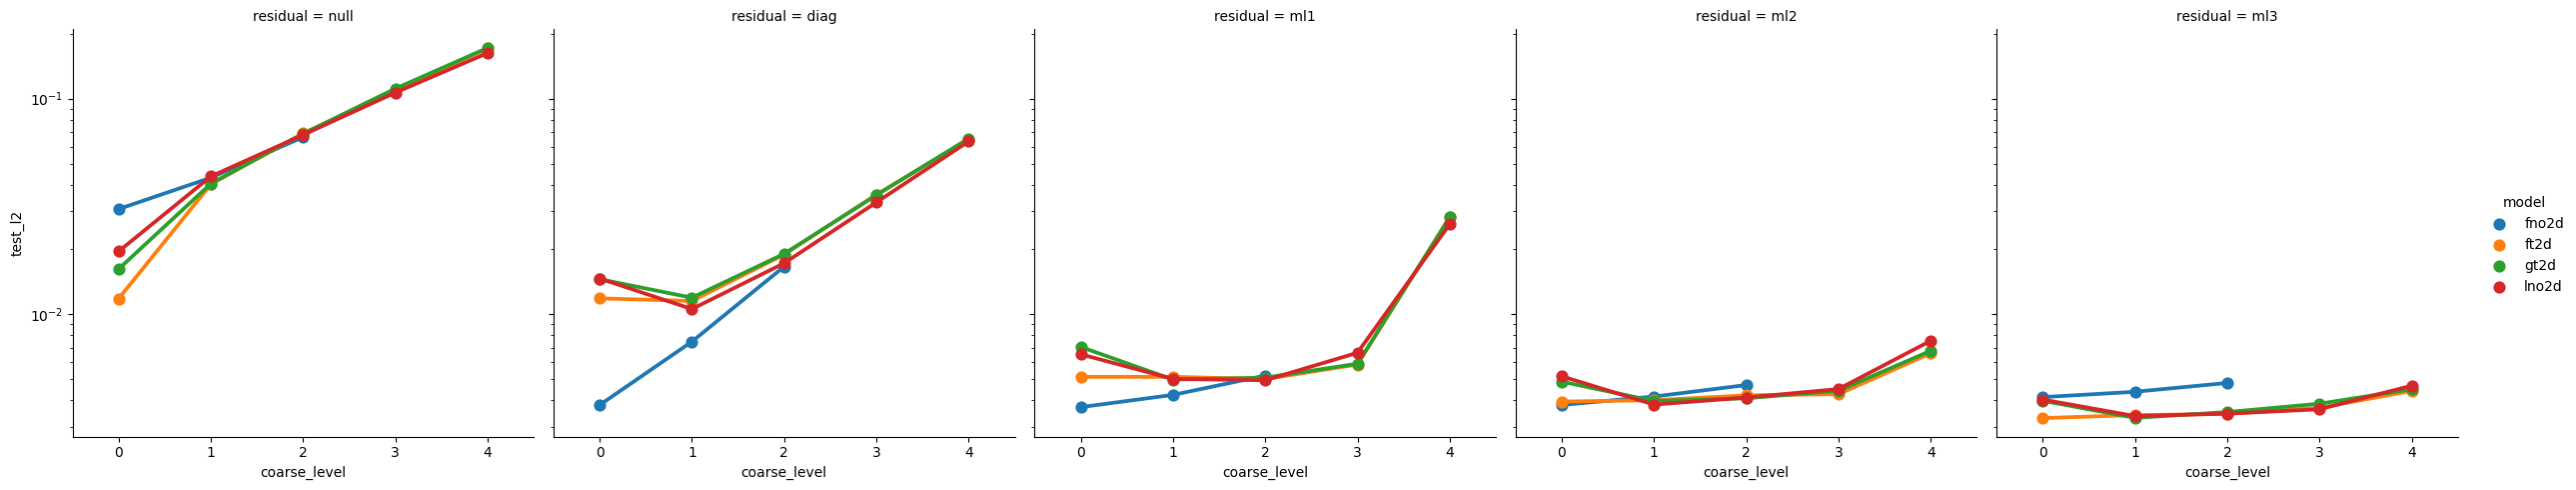

In [13]:
sub_df = log_agg_df[(log_agg_df.resolution == 85) & (log_agg_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='point', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')

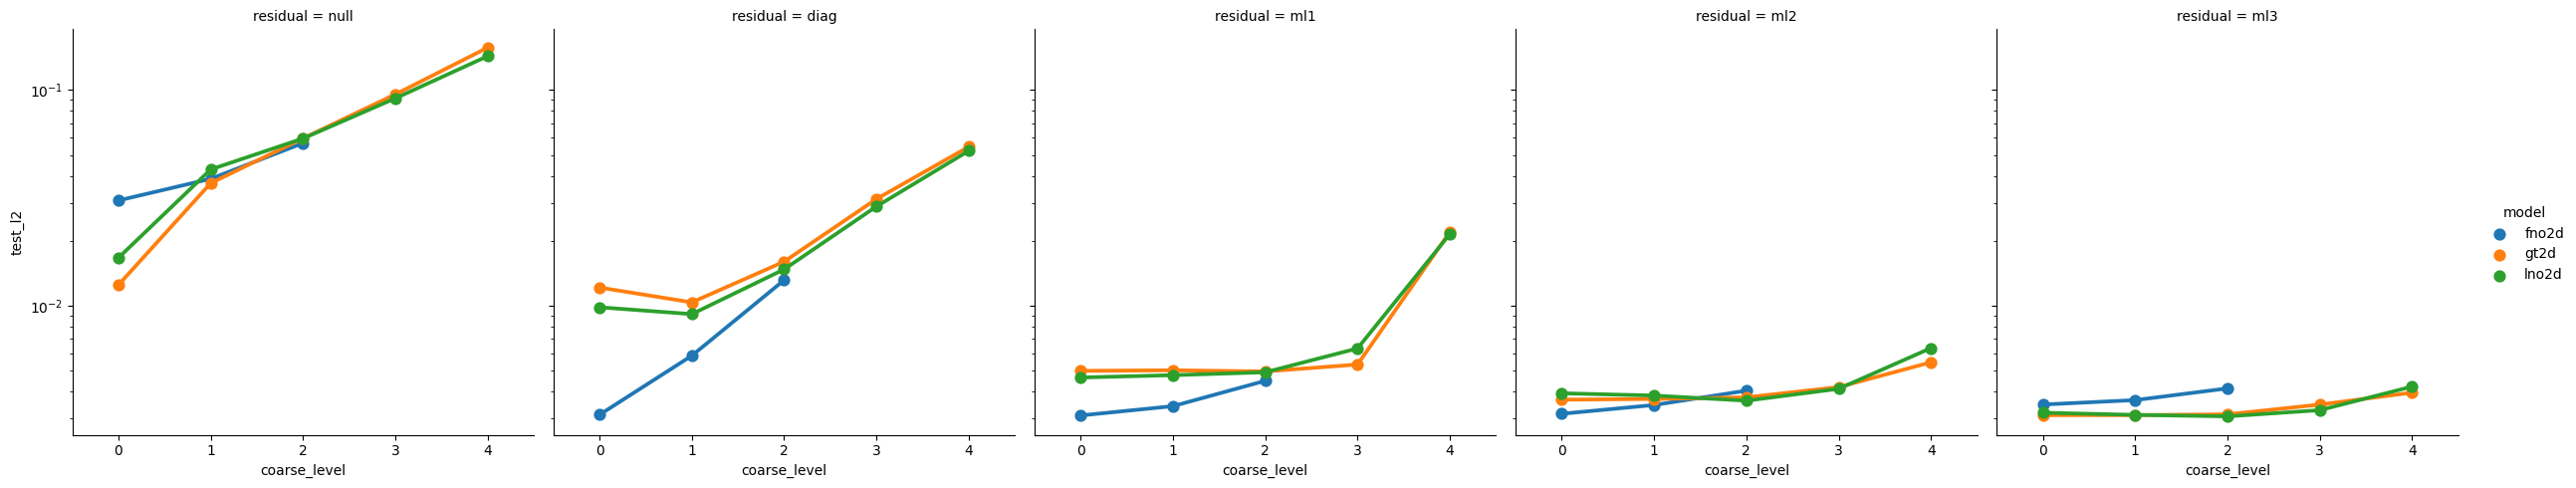

In [12]:
sub_df = log_agg_df[(log_agg_df.resolution == 106) & (log_agg_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='point', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')

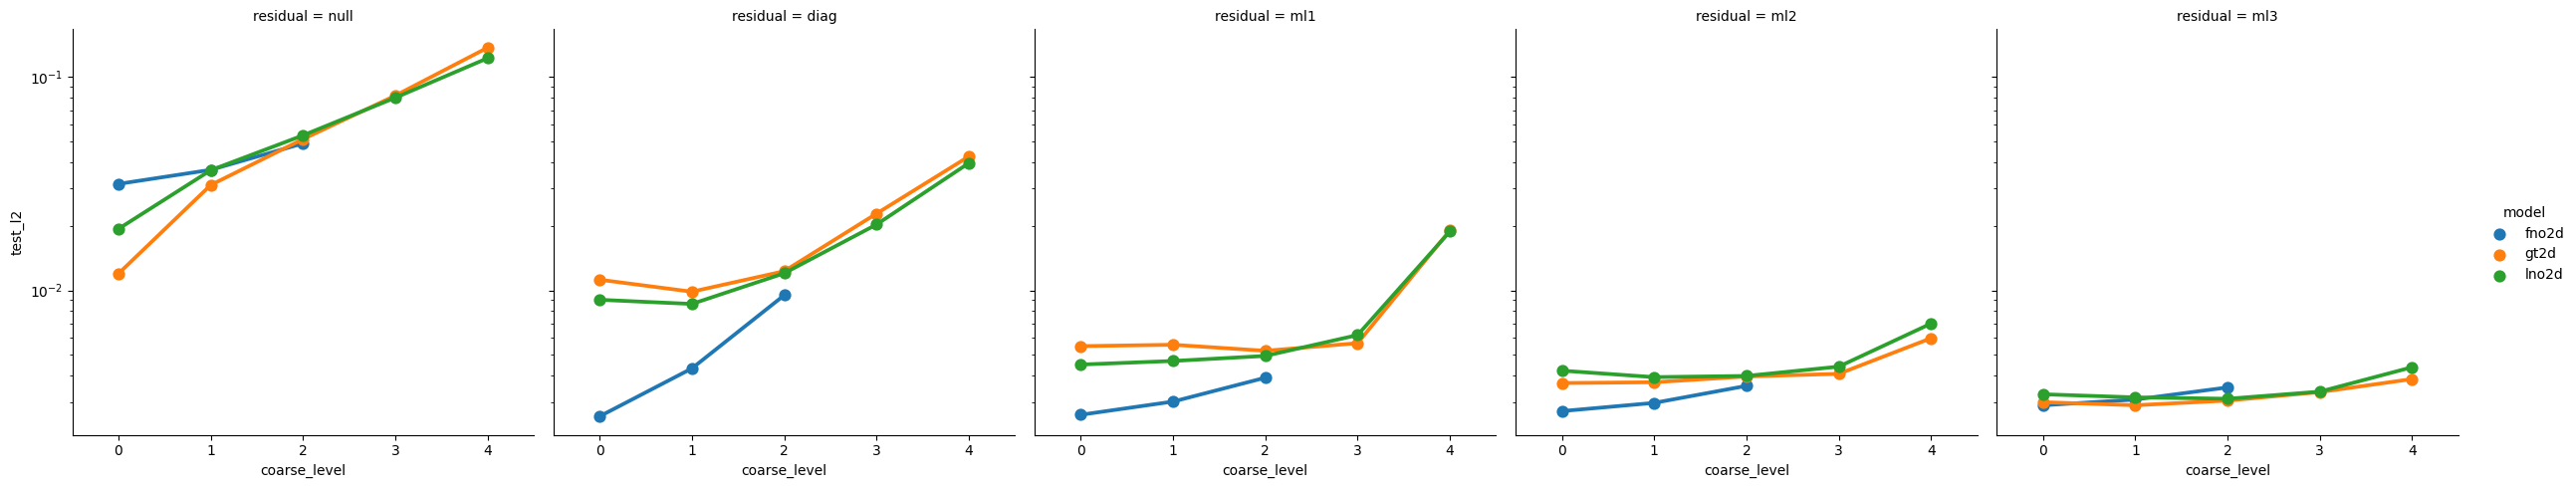

In [11]:
sub_df = log_agg_df[(log_agg_df.resolution == 141) & (log_agg_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='point', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')


In [10]:
# sub_df = log_df[(log_df.resolution == 512) & (log_df.dataset == 'poisson') & (log_df.model == 'gt1d')]
# g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='strip', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], hue='model')
# g.set(yscale='log')